In [ ]:
import tensorflow as tf
from pathlib import Path


In [3]:
model = tf.keras.models.load_model(
    "../models/unet_best.keras"
)

2026-08-17 23:42:35.099408: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-08-17 23:42:35.207973: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-08-17 23:42:35.211324: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [9]:
datasetPath = Path("../dataset/data_wound_seg_256")
test_images = datasetPath / "test_images"
test_masks= datasetPath / "test_masks"

In [10]:
test_images_path = sorted(test_images.glob("*.png"))
test_masks_path = sorted(test_masks.glob("*.png"))

In [14]:
import numpy as np
from PIL import Image
images = np.array(Image.open(test_images_path[0])).astype(np.float32) /255
masks = np.array(Image.open(test_masks_path[0]).convert("L")).astype(np.float32) /255

In [15]:
dice_score = []
iou_score = []

In [17]:

test_images_path = [str(p) for p in test_images_path]
test_masks_path = [str(p) for p in test_masks_path]

In [18]:
test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_images_path, test_masks_path)
)

In [19]:
BATCH_SIZE = 2

In [21]:
def load_image_masks(image_path, masks_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.convert_image_dtype(image, tf.float32)

    masks = tf.io.read_file(masks_path)
    masks = tf.image.decode_png(masks, channels=1)
    masks = tf.image.convert_image_dtype(masks, tf.float32)

    return image, masks

In [22]:
test_dataset = test_dataset.map(load_image_masks)
test_dataset = test_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

In [23]:
for images, masks in test_dataset:
    predictions = model.predict(
        images,
        verbose = 0
    )
    for i in range(images.shape[0]):
        gt = masks[i].numpy().squeeze() > 0.5
        pred = predictions[i].squeeze() > 0.5
        intersections  = np.logical_and(
            gt,
            pred
        ).sum()
        union = np.logical_or(
            gt,pred
        ).sum()
        dice = (2 * intersections) / (
            gt.sum() + pred.sum() + 1e-7
        )

        iou = intersections / (1e-7 + union)

        dice_score.append(dice)
        iou_score.append(iou)

        

2026-08-18 00:20:29.801617: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907


In [24]:
print("Test images:", len(dice_score))
print("Mean DIce", np.mean(dice_score))
print("mean IoU", np.mean(iou_score))

Test images: 552
Mean DIce 0.7123712649428936
mean IoU 0.6147388006588265


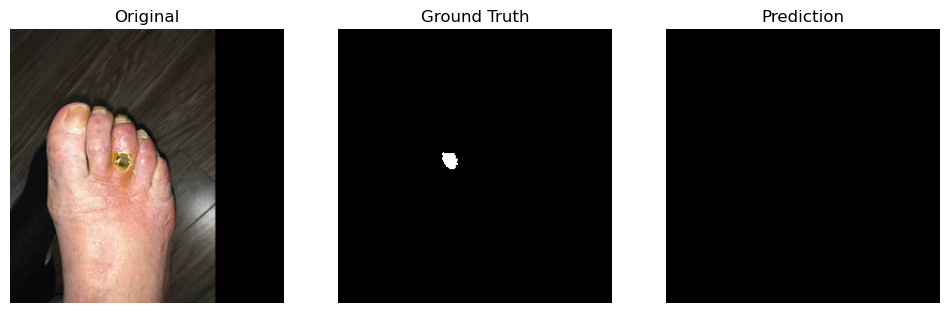

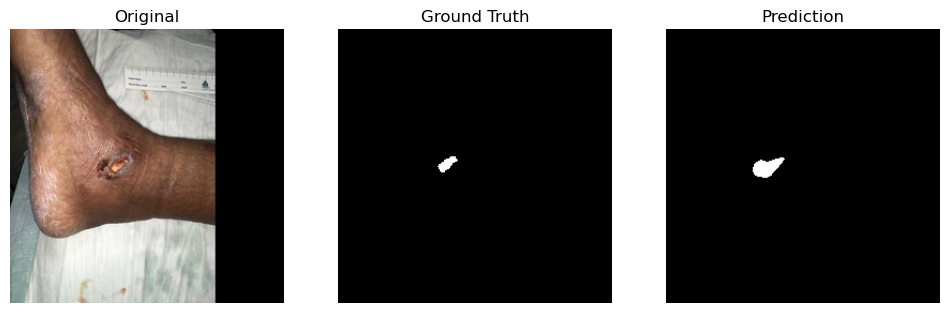

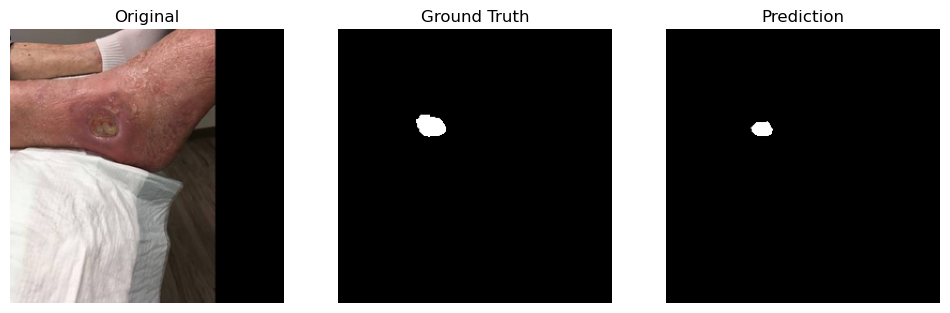

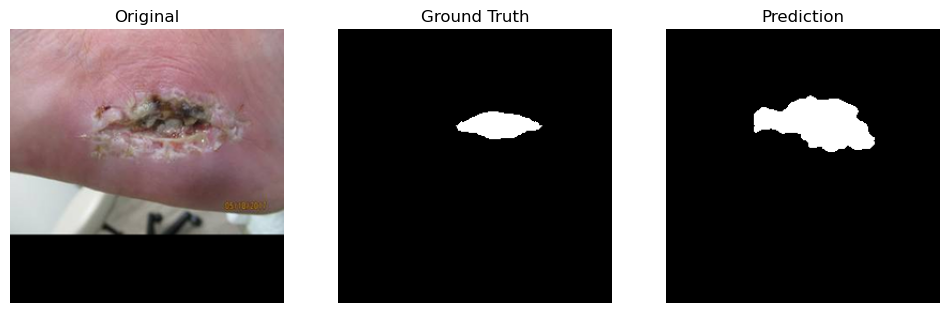

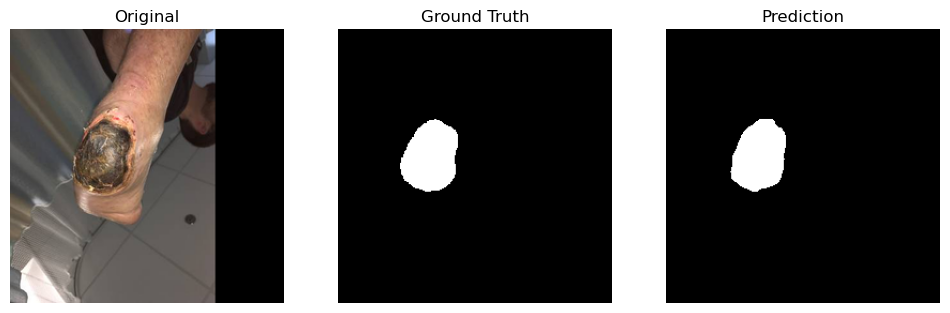

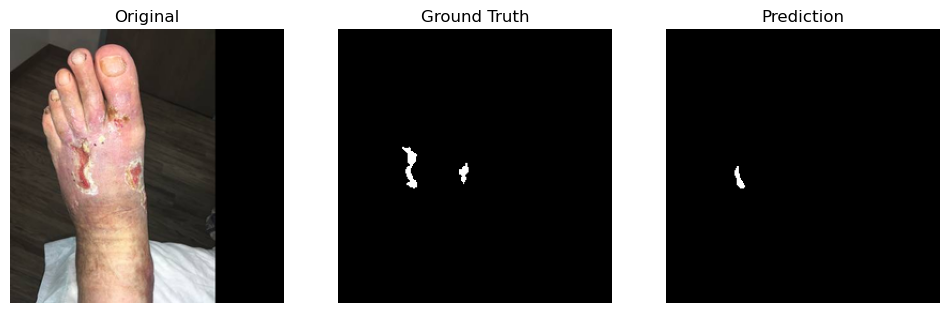

In [25]:
import matplotlib.pyplot as plt

for images, masks in test_dataset.take(3):

    predictions = model.predict(images, verbose=0)

    for i in range(images.shape[0]):

        plt.figure(figsize=(12, 4))

        plt.subplot(1, 3, 1)
        plt.imshow(images[i])
        plt.title("Original")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(masks[i].numpy().squeeze(), cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(
            predictions[i].squeeze() > 0.5,
            cmap="gray"
        )
        plt.title("Prediction")
        plt.axis("off")

        plt.show()